In [34]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import networkx as nx

In [35]:
from skimage.segmentation import slic, mark_boundaries
from skimage.color import rgb2lab
from skimage import io
from skimage import graph

In [4]:
image_path = "data1.png"
image = io.imread(image_path)
print(image.shape)

(1024, 1024, 3)


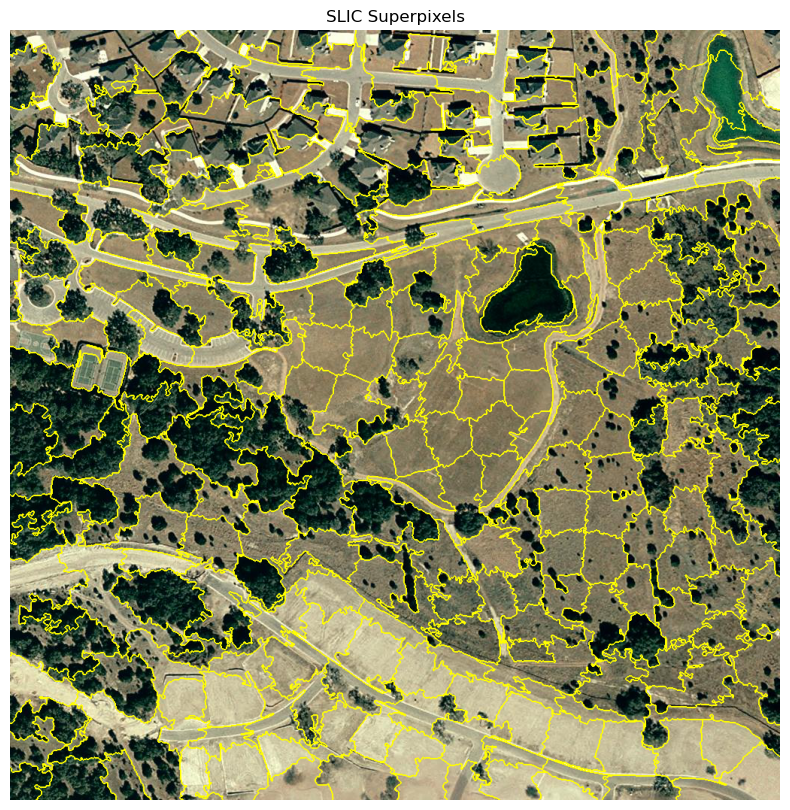

In [37]:
segments = slic(
    image,
    n_segments=400,
    compactness=10,
    sigma=1,
    start_label=1
)
plt.figure(figsize=(10,10))
plt.imshow(mark_boundaries(image, segments))
plt.title("SLIC Superpixels")
plt.axis("off")
plt.show()

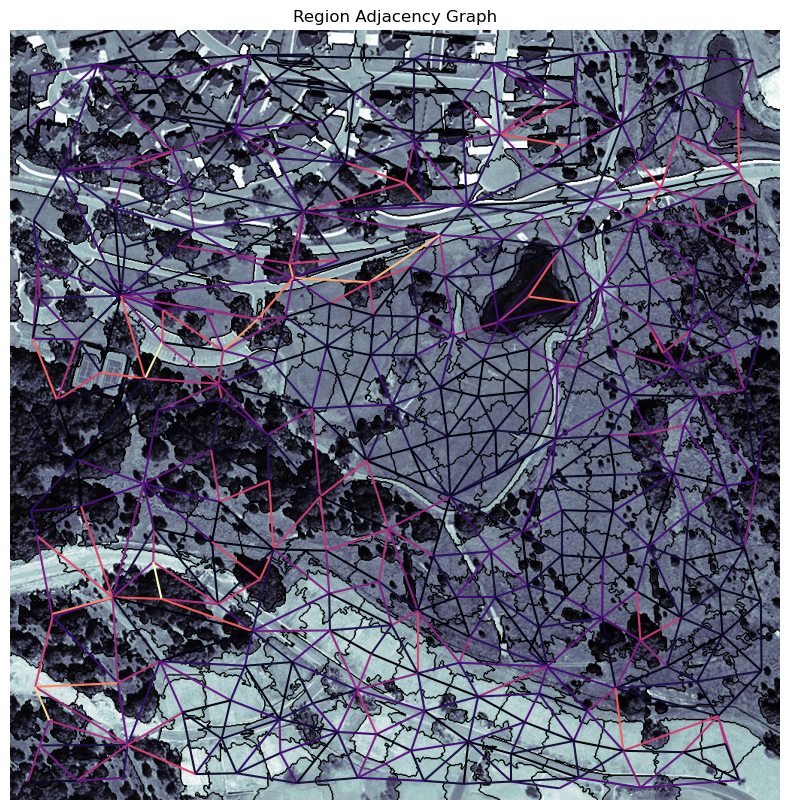

In [79]:
rag = graph.rag_mean_color(image, segments)
fig, ax = plt.subplots(figsize=(10,10))
graph.show_rag(segments, rag, image, ax=ax)
plt.title("Region Adjacency Graph")
plt.axis("off")
plt.show()

In [39]:
adj_matrix = nx.adjacency_matrix(rag).todense()
print(adj_matrix.shape)

(248, 248)


In [40]:
node_features = []

for region in np.unique(segments):
    mask = segments == region
    pixels = image[mask]
    mean_color = pixels.mean(axis=0)
    node_features.append(mean_color)

node_features = np.array(node_features)
print(node_features.shape)

(248, 3)


In [42]:
texture_features = []

for region in np.unique(segments):
    mask = segments == region
    pixels = image[mask]
    std_texture = pixels.std(axis=0)
    texture_features.append(std_texture)

texture_features = np.array(texture_features)
features = np.concatenate([node_features, texture_features], axis=1)
print(features.shape)

(248, 6)


In [43]:
for edge in rag.edges:
    n1, n2 = edge
    diff = np.linalg.norm(features[n1-1] - features[n2-1])
    rag[n1][n2]['weight'] = diff

In [44]:
def weight_mean_color(graph, src, dst, n):
    default = {'weight': 0.0}

    weight_src = graph[src].get(n, default)['weight']
    weight_dst = graph[dst].get(n, default)['weight']

    return {
        'weight': (weight_src + weight_dst) / 2.0
    }

In [45]:
def merge_boundary(graph, src, dst):
    pass

In [77]:
labels2 = graph.merge_hierarchical(
    segments,
    rag,
    thresh=4.205,
    rag_copy=True,
    in_place_merge=False,
    merge_func=merge_boundary,
    weight_func=weight_mean_color 
)

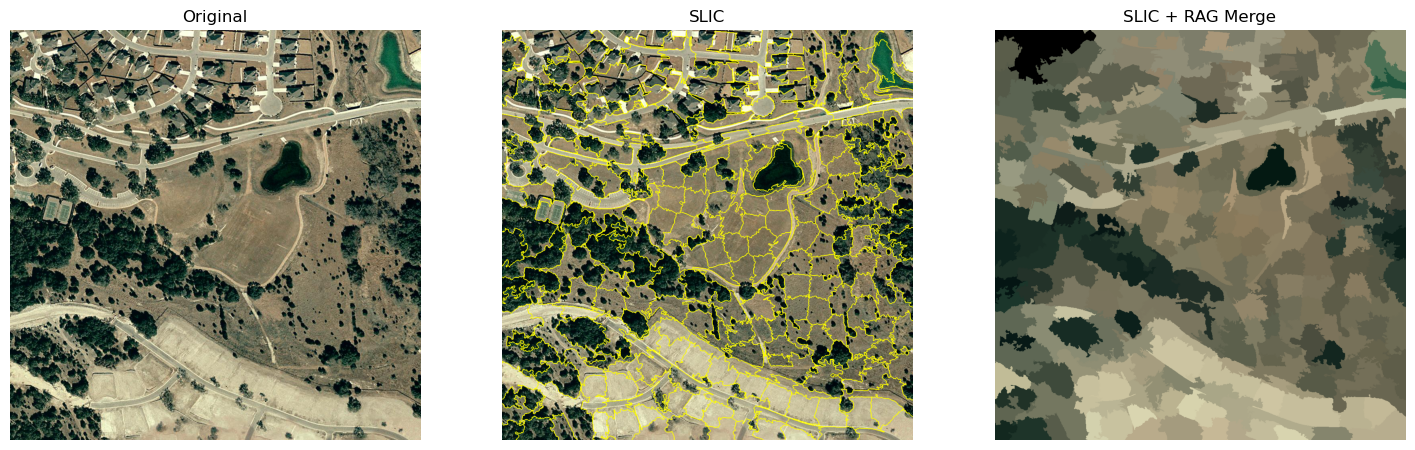

In [69]:
from skimage.color import label2rgb
fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(image)
ax[0].set_title("Original")

ax[1].imshow(mark_boundaries(image, segments))
ax[1].set_title("SLIC")

ax[2].imshow(label2rgb(labels2, image, kind='avg'))
ax[2].set_title("SLIC + RAG Merge")

for a in ax:
    a.axis("off")

plt.show()

In [78]:
print("After merge:", len(np.unique(labels2)))

After merge: 237


In [60]:
import rasterio
from rasterio.features import shapes
import geopandas as gpd

In [61]:
image_path = "data1.png"

with rasterio.open(image_path) as src:
    image = src.read([1,2,3])
    transform = src.transform
    crs = src.crs

image = np.transpose(image, (1,2,0))

c:\Users\hp\anaconda3\envs\geo\lib\site-packages\rasterio\__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [62]:
with rasterio.open(
    "slic_labels.tif",
    "w",
    driver="GTiff",
    height=segments.shape[0],
    width=segments.shape[1],
    count=1,
    dtype='int32',
    crs=crs,
    transform=transform
) as dst:
    dst.write(segments, 1)

c:\Users\hp\anaconda3\envs\geo\lib\site-packages\rasterio\__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [63]:
results = []


segments = segments.astype(np.int32)

for geom, val in shapes(segments, transform=transform):
    results.append({
        'geometry': geom,
        'properties': {'label': int(val)}
    })

gdf = gpd.GeoDataFrame.from_features(results, crs=crs)
gdf.to_file("slic_vector.shp") 

c:\Users\hp\anaconda3\envs\geo\lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [64]:
with rasterio.open(
    "slic_rag_labels.tif",
    "w",
    driver="GTiff",
    height=labels2.shape[0],
    width=labels2.shape[1],
    count=1,
    dtype='int32',
    crs=crs,
    transform=transform
) as dst:
    dst.write(labels2, 1)

c:\Users\hp\anaconda3\envs\geo\lib\site-packages\rasterio\__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [65]:
results2 = []
labels2 = labels2.astype(np.int32)
for geom, val in shapes(labels2, transform=transform):
    results2.append({
        'geometry': geom,
        'properties': {'label': int(val)}
    })

gdf2 = gpd.GeoDataFrame.from_features(results2, crs=crs)
gdf2.to_file("slic_rag_vector.shp")

c:\Users\hp\anaconda3\envs\geo\lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [ ]:

from skimage.feature import graycomatrix, graycoprops
from skimage.filters import gabor

with rasterio.open("data1.png") as src:
    transform = src.transform
    crs = src.crs

# STEP 1: Mean reflectance raster

mean_image = np.zeros_like(image)

results = []

# Helper function for GLCM

def get_glcm_features(region):

    if region.shape[0] < 2 or region.shape[1] < 2:
        return 0, 0, 0, 0

    glcm = graycomatrix(
        region,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = float(graycoprops(glcm, 'contrast')[0, 0])
    homogeneity = float(graycoprops(glcm, 'homogeneity')[0, 0])
    energy = float(graycoprops(glcm, 'energy')[0, 0])
    correlation = float(graycoprops(glcm, 'correlation')[0, 0])

    return contrast, homogeneity, energy, correlation

# ---------------------------------------------------
# STEP 3: Loop over segments
# ---------------------------------------------------

for seg_val in np.unique(segments):

    mask = segments == seg_val

    # ------------------------------------------------
    # Spectral means
    # ------------------------------------------------

    mean_r = float(image[:, :, 0][mask].mean())
    mean_g = float(image[:, :, 1][mask].mean())
    mean_b = float(image[:, :, 2][mask].mean())

    mean_image[:, :, 0][mask] = mean_r
    mean_image[:, :, 1][mask] = mean_g
    mean_image[:, :, 2][mask] = mean_b

    # ------------------------------------------------
    # Bounding box
    # ------------------------------------------------

    coords = np.where(mask)

    minr, maxr = coords[0].min(), coords[0].max()
    minc, maxc = coords[1].min(), coords[1].max()

    local_mask = mask[minr:maxr+1, minc:maxc+1]

    # ------------------------------------------------
    # Band extraction
    # ------------------------------------------------

    red = image[minr:maxr+1, minc:maxc+1, 0].copy()
    green = image[minr:maxr+1, minc:maxc+1, 1].copy()
    blue = image[minr:maxr+1, minc:maxc+1, 2].copy()

    red[~local_mask] = 0
    green[~local_mask] = 0
    blue[~local_mask] = 0

    # ------------------------------------------------
    # GLCM per band
    # ------------------------------------------------

    r_feat = get_glcm_features(red.astype(np.uint8))
    g_feat = get_glcm_features(green.astype(np.uint8))
    b_feat = get_glcm_features(blue.astype(np.uint8))

    contrast = np.mean([r_feat[0], g_feat[0], b_feat[0]])
    homogeneity = np.mean([r_feat[1], g_feat[1], b_feat[1]])
    energy = np.mean([r_feat[2], g_feat[2], b_feat[2]])
    correlation = np.mean([r_feat[3], g_feat[3], b_feat[3]])

    # ------------------------------------------------
    # Gabor per band
    # ------------------------------------------------

    gabor_r, _ = gabor(red, frequency=0.2)
    gabor_g, _ = gabor(green, frequency=0.2)
    gabor_b, _ = gabor(blue, frequency=0.2)

    gabor_mean = float(np.mean([
        gabor_r.mean(),
        gabor_g.mean(),
        gabor_b.mean()
    ]))

    gabor_std = float(np.mean([
        gabor_r.std(),
        gabor_g.std(),
        gabor_b.std()
    ]))

    # ------------------------------------------------
    # Tamura
    # ------------------------------------------------

    std = np.mean([
        red.std(),
        green.std(),
        blue.std()
    ])

    if std == 0:
        tamura_contrast = 0
    else:
        kurt = np.mean((red - red.mean())**4) / (red.std()**4 + 1e-6)
        tamura_contrast = float(std / (kurt**0.25))

    tamura_coarseness = float(np.mean([
        cv2.Laplacian(red, cv2.CV_64F).var(),
        cv2.Laplacian(green, cv2.CV_64F).var(),
        cv2.Laplacian(blue, cv2.CV_64F).var()
    ]))

    # ------------------------------------------------
    # Polygon extraction
    # ------------------------------------------------

    for geom, value in shapes(
        mask.astype(np.uint8),
        mask=mask,
        transform=transform
    ):

        results.append({
            'geometry': geom,
            'properties': {

                'label': int(seg_val),

                # spectral
                'mean_red': mean_r,
                'mean_green': mean_g,
                'mean_blue': mean_b,

                # texture
                'contrast': contrast,
                'homogeneity': homogeneity,
                'energy': energy,
                'correlation': correlation,

                # gabor
                'gabor_mean': gabor_mean,
                'gabor_std': gabor_std,

                # tamura
                'tamura_contrast': tamura_contrast,
                'tamura_coarseness': tamura_coarseness
            }
        })

# ---------------------------------------------------
# STEP 4: Save raster
# ---------------------------------------------------

with rasterio.open(
    "mean_reflectance.tif",
    "w",
    driver="GTiff",
    height=mean_image.shape[0],
    width=mean_image.shape[1],
    count=3,
    dtype=mean_image.dtype,
    crs=crs,
    transform=transform
) as dst:

    dst.write(mean_image[:, :, 0], 1)
    dst.write(mean_image[:, :, 1], 2)
    dst.write(mean_image[:, :, 2], 3)

# ---------------------------------------------------
# STEP 5: Save vector
# ---------------------------------------------------

gdf = gpd.GeoDataFrame.from_features(results, crs=crs)

gdf.to_file("slic_multiband_texture_vector.shp")

print("Done")

c:\Users\hp\anaconda3\envs\geo\lib\site-packages\rasterio\__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Done


c:\Users\hp\anaconda3\envs\geo\lib\site-packages\rasterio\__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
C:\Users\hp\AppData\Local\Temp\ipykernel_9140\1970192019.py:206: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file("slic_multiband_texture_vector.shp")
c:\Users\hp\anaconda3\envs\geo\lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
c:\Users\hp\anaconda3\envs\geo\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'homogeneity' to 'homogeneit'
  ogr_write(
c:\Users\hp\anaconda3\envs\geo\lib\site-packages\pyogrio\raw.py:723: RuntimeWarnin